Synthesis and Application

We will now translate these technical findings into the final "Institutional Priority Matrix." This notebook will generate a strategic "Blueprint" that the School of IT can use for service intervention.

Strategic Synthesis of Predictive Drivers

 We combine the SHAP values with the model's predictions to create a service risk score. We categorize features into "Critical Fixes" (High impact, likely dissatisfied) and "Retention Strengths" (High impact, likely satisfied).

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load artifacts from Notebook 03
model = joblib.load('../results/final_binary_model.pkl')
features = joblib.load('../results/final_features_list.pkl')
shap_v = joblib.load('../results/shap_values_binary.pkl')

# Create a Feature Importance Ranking for stakeholders
# Since it's binary, we take the mean absolute SHAP values
import numpy as np
feature_importance = pd.DataFrame({
    'Service_Indicator': features,
    'Importance_Score': np.abs(shap_v).mean(axis=0)
}).sort_values(by='Importance_Score', ascending=False)

print("--- Institutional Priority Ranking ---")
print(feature_importance)

--- Institutional Priority Ranking ---
            Service_Indicator  Importance_Score
1       acad_grading_fairness          1.105538
0   serv_staff_responsiveness          0.953009
3       serv_admin_efficiency          0.399875
4            it_support_avail          0.358212
7     acad_consultation_avail          0.342802
9          acad_qual_teaching          0.243234
8               lib_materials          0.149343
2             needs_alignment          0.096296
11                    program          0.086975
10                 year_level          0.012798
6                  lib_spaces          0.000000
5              fac_classrooms          0.000000
12              mode_of_study          0.000000


Generating the Service Priority Matrix

We translate the technical importance scores into proposed priority levels. This is the non-technical output that a Dean or Director can use to allocate budget or staff training.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_7892\918031320.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance_Score', y='Service_Indicator', palette='mako')


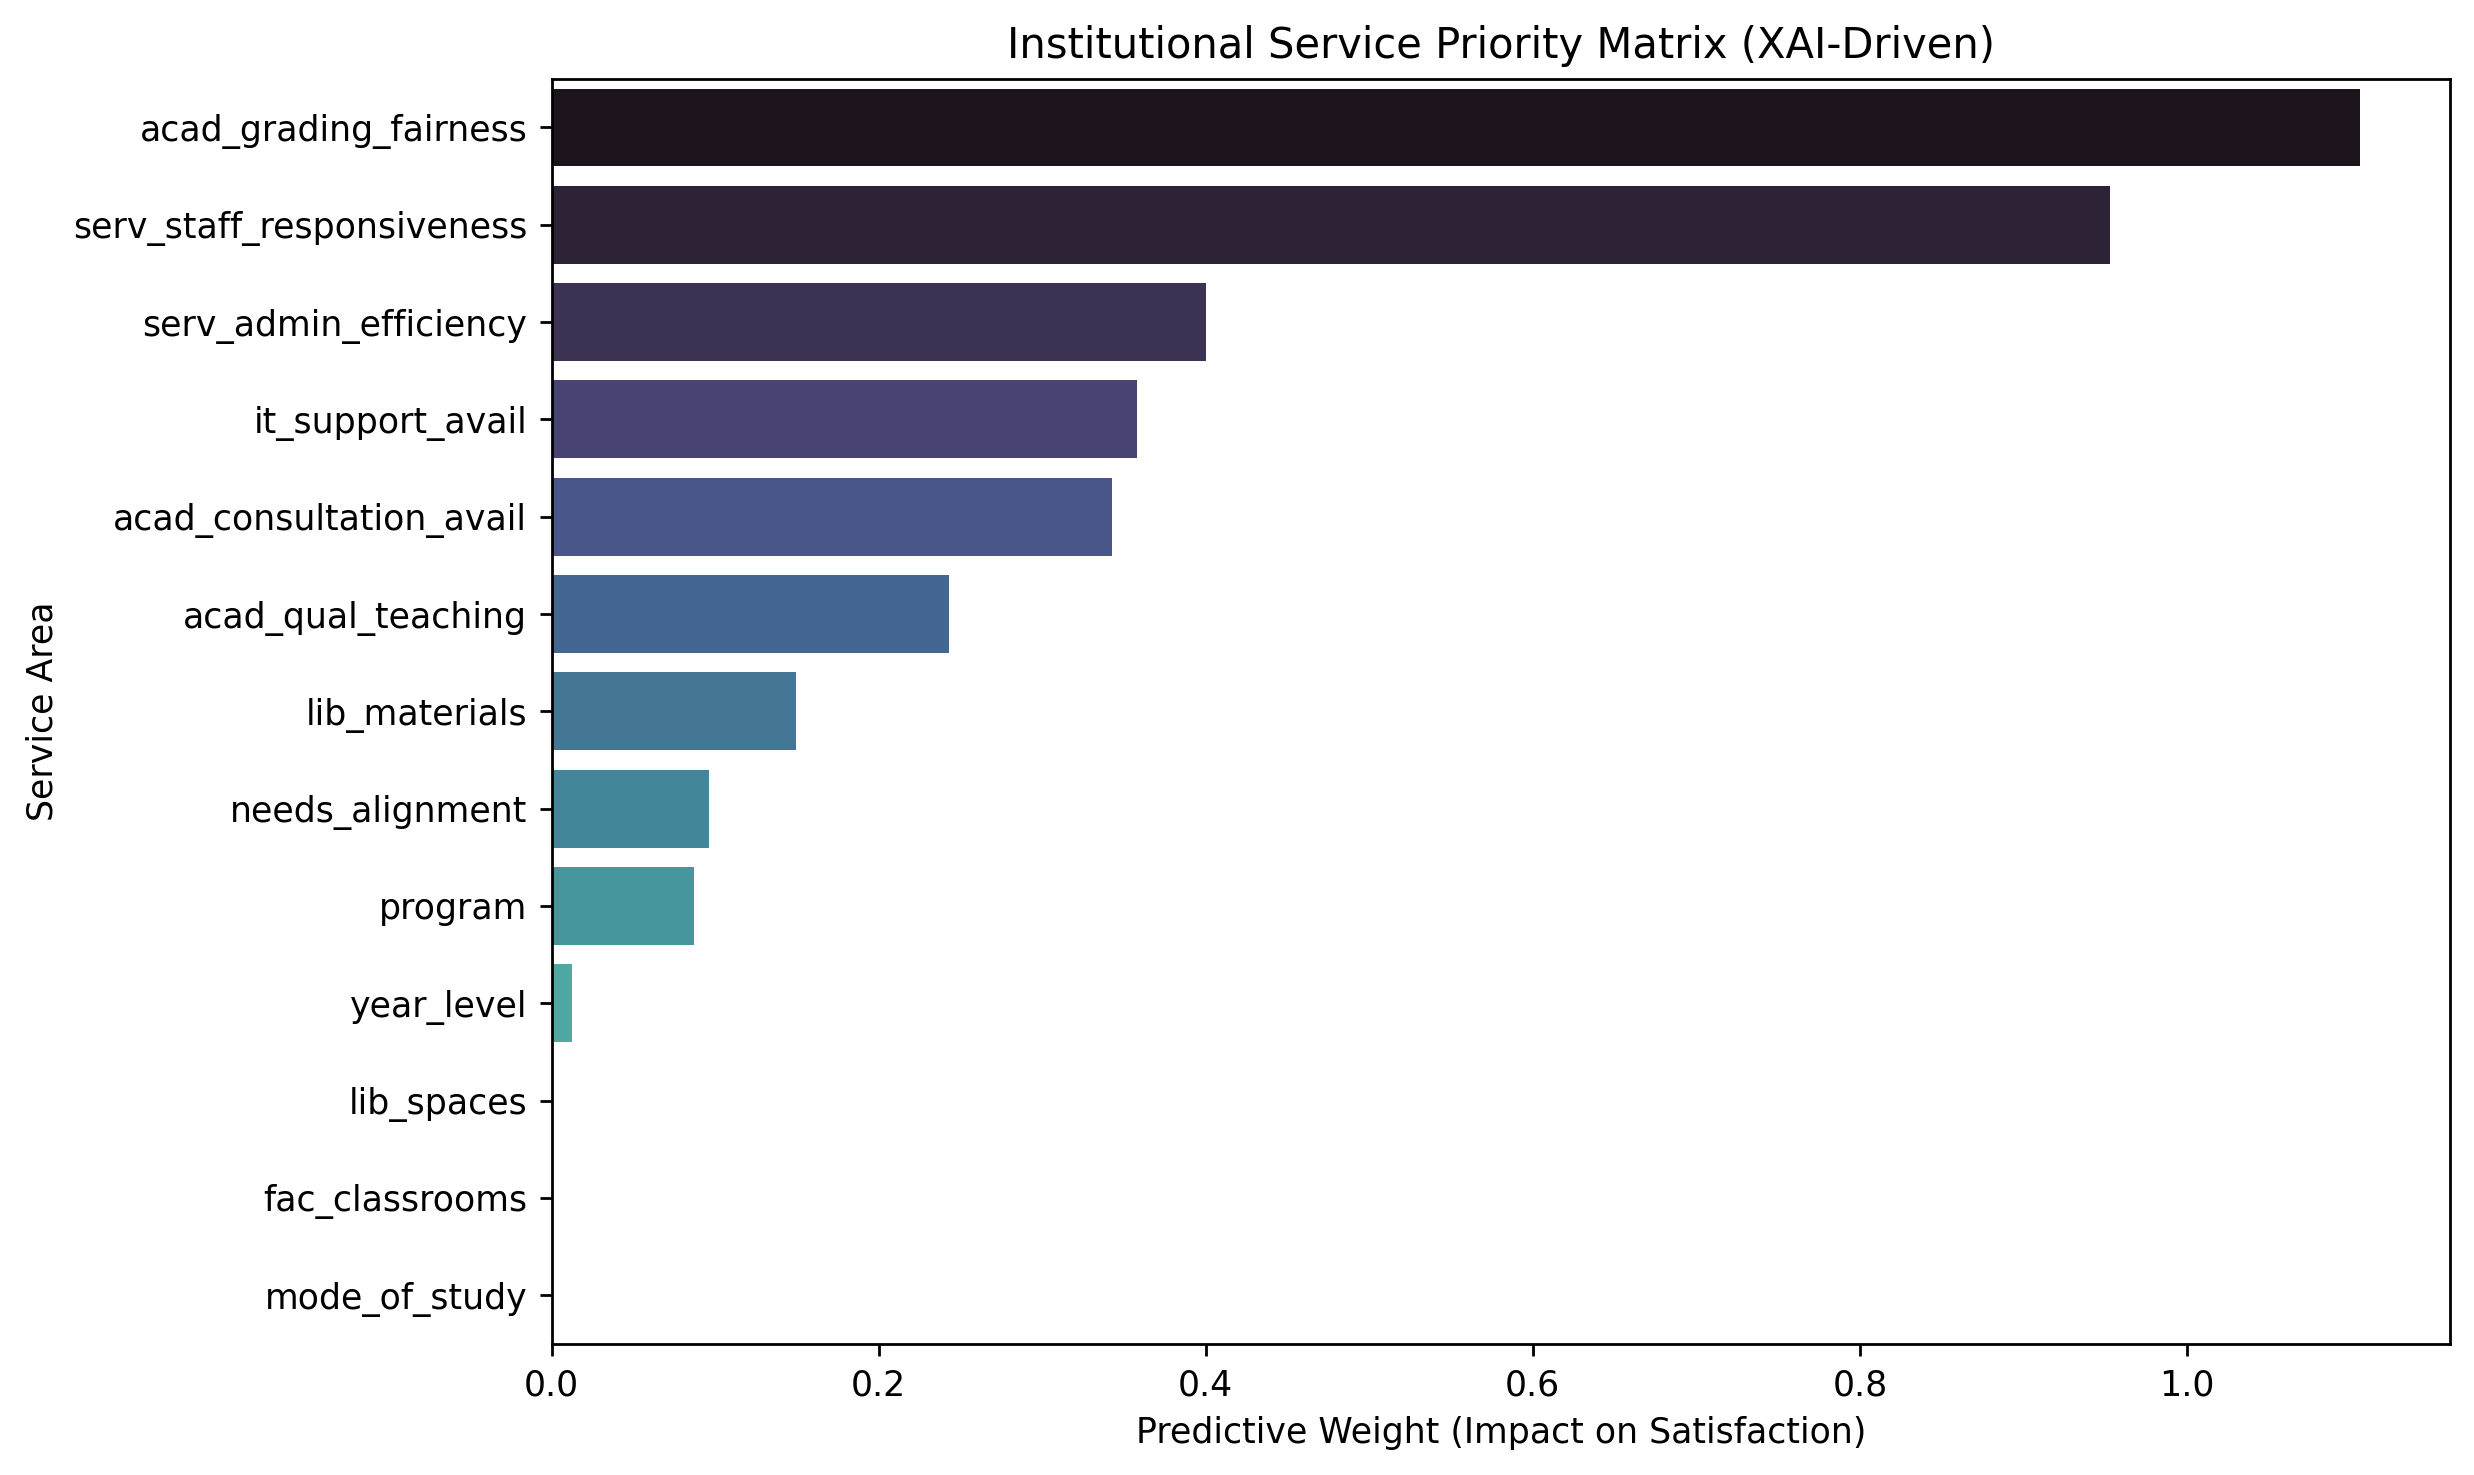

In [2]:
def categorize_priority(score):
    if score > 0.5: return "P1: Immediate Intervention"
    elif score > 0.2: return "P2: Process Optimization"
    else: return "P3: Monitoring/Maintenance"

feature_importance['Action_Plan'] = feature_importance['Importance_Score'].apply(categorize_priority)

# Visualization for the Final Report
plt.figure(figsize=(10, 6), dpi=250)
sns.barplot(data=feature_importance, x='Importance_Score', y='Service_Indicator', palette='mako')
plt.title("Institutional Service Priority Matrix (XAI-Driven)")
plt.xlabel("Predictive Weight (Impact on Satisfaction)")
plt.ylabel("Service Area")
plt.tight_layout()
plt.savefig('../results/final_priority_matrix.png')
plt.show()

Practical Application (The Student Flagging System)

 This code demonstrates the model in action. It takes new, "unseen" student data and flags whether they are "Satisfied" or "At-Risk," providing a sample of the predictive dashboard's logic.

In [3]:
# Sample implementation of a 'Predictive Dashboard' logic
def evaluate_student_risk(new_student_data):
    # Ensure data matches the 'slim' feature set
    prediction = model.predict(new_student_data)
    probability = model.predict_proba(new_student_data)[0][1]
    
    sentiment = "Satisfied" if prediction == 1 else "At-Risk"
    confidence = probability if prediction == 1 else (1 - probability)
    
    return f"Status: {sentiment} ({confidence*100:.2f}% confidence)"

# Logic Test (using a row from the holdout)
sample_student = pd.read_csv('../data/processed/real_test_holdout.csv').drop(columns=['target_satisfaction']).iloc[[0]][features]
# Ensure categorical types for sample
for col in ['year_level', 'program', 'mode_of_study']:
    if col in sample_student.columns:
        sample_student[col] = sample_student[col].astype('category')

print(f"Sample Student Flagging Result: {evaluate_student_risk(sample_student)}")

Sample Student Flagging Result: Status: Satisfied (97.28% confidence)
